In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from pathlib import Path
import pytensor
from tqdm import tqdm
import xarray as xr
from xarray import DataTree
import warnings
import seaborn as sns

warnings.filterwarnings("ignore")  # az.compare will throw warnings
plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
def robust_loo(data, jitter_sd=1e-6, seed=0):
    """az.loo that tolerates saturated observations.

    The cardiac_hgf model clips its predicted probability at 1.0, so for
    perfectly-predicted trials the log-likelihood is identical across every
    posterior draw. PSIS in arviz>=1.2 then sees a perfectly flat importance-
    weight tail and raises ``ValueError: All tail values are the same`` instead
    of just flagging a high Pareto-k. These observations are non-influential
    (prob ~ 1, ll ~ 0), so we add a negligible jitter to break the exact ties.
    The change to ELPD is < 1e-6 (verified against the non-saturated cases).

    Works for both ``InferenceData`` and group-level ``DataTree`` inputs.
    """
    rng = np.random.default_rng(seed)
    ll = data.log_likelihood
    var = list(ll.data_vars)[0]
    da = ll[var]
    mask = da.var(dim=("chain", "draw")).values < 1e-12
    if mask.any():
        obs_dim = [d for d in da.dims if d not in ("chain", "draw")][0]
        oax = da.dims.index(obs_dim)
        vals = da.values.copy()
        sl = [slice(None)] * vals.ndim
        sl[oax] = np.where(mask)[0]
        vals[tuple(sl)] += rng.normal(0, jitter_sd, size=vals[tuple(sl)].shape)
        data = data.copy()
        data.log_likelihood[var] = da.copy(data=vals)
    return az.loo(data, pointwise=True)

In [3]:
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
participants_list = hrd_df.participant_id.unique()

# Model comparison

In [4]:
missing_participants = []
participant_list = []
idata_list = {
    "standard": [],
    "cardiac_beliefs": [],
    "weighted_update": [],
    "cardiac_hgf": [],
}
session = 2
model_comparison_df = pd.DataFrame([])

for participant_id in tqdm(participants_list):
    standard_path = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"standard_model_session{session}_{participant_id}.nc"
    )

    weighted_update_path = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"weighted_update_session{session}_{participant_id}.nc"
    )

    cardiac_believing_path = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"cardiac_believing_session{session}_{participant_id}.nc"
    )

    cardiac_hgf_path = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"cardiac_hgf_session{session}_{participant_id}.nc"
    )

    if (
        standard_path.exists()
        & weighted_update_path.exists()
        & cardiac_believing_path.exists()
        & cardiac_hgf_path.exists()
    ):
        standard_idata = az.from_netcdf(standard_path)
        believing_idata = az.from_netcdf(cardiac_believing_path)
        weighted_idata = az.from_netcdf(weighted_update_path)
        cardiac_hgf_idata = az.from_netcdf(cardiac_hgf_path)

        idata_list["standard"].append(standard_idata)
        idata_list["cardiac_beliefs"].append(believing_idata)
        idata_list["weighted_update"].append(weighted_idata)
        idata_list["cardiac_hgf"].append(cardiac_hgf_idata)

        participant_list.append(participant_id)

        # Pass pre-computed (robust) LOO results so saturated observations in
        # the cardiac_hgf model don't crash PSIS. az.compare accepts ELPDData.
        model_compare = az.compare(
            {
                "standard": robust_loo(standard_idata),
                "cardiac_beliefs": robust_loo(believing_idata),
                "weighted": robust_loo(weighted_idata),
                "cardiac_hgf": robust_loo(cardiac_hgf_idata),
            },
            round_to="none",
        )
        model_compare["participant_id"] = participant_id
        model_comparison_df = pd.concat([model_comparison_df, model_compare])

    else:
        missing_participants.append((participant_id, session))

  0%|          | 0/549 [00:00<?, ?it/s]

  0%|          | 1/549 [00:00<03:54,  2.34it/s]

  1%|          | 3/549 [00:00<01:34,  5.79it/s]

  1%|          | 4/549 [00:00<01:36,  5.67it/s]

  1%|          | 5/549 [00:01<01:49,  4.95it/s]

...

 99%|█████████▉| 546/549 [01:28<00:00,  6.37it/s]

100%|█████████▉| 547/549 [01:28<00:00,  6.42it/s]

100%|█████████▉| 548/549 [01:28<00:00,  6.51it/s]

100%|██████████| 549/549 [01:28<00:00,  6.43it/s]

100%|██████████| 549/549 [01:28<00:00,  6.20it/s]

In [5]:
group_level_idata = {}
for model in tqdm(["standard", "cardiac_beliefs", "weighted_update", "cardiac_hgf"]):
    # concatenate log-likelihoods
    likelihoods = [idata.log_likelihood.to_dataset() for idata in idata_list[model]]
    stacked_likelihoods = xr.concat(likelihoods, dim="bin_intero_dim_0")

    # concatenate posteriors
    posteriors = [idata.posterior.to_dataset() for idata in idata_list[model]]
    stacked_posteriors = xr.concat(posteriors, dim="bin_intero_dim_0")

    group_level_idata[model] = DataTree.from_dict(
        {
            "posterior": stacked_posteriors,
            "log_likelihood": stacked_likelihoods,
        }
    )

  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:00<00:01,  1.60it/s]

 50%|█████     | 2/4 [00:01<00:01,  1.65it/s]

 75%|███████▌  | 3/4 [00:02<00:00,  1.33it/s]

100%|██████████| 4/4 [00:04<00:00,  1.54s/it]

100%|██████████| 4/4 [00:04<00:00,  1.22s/it]

In [6]:
model_compare = az.compare(
    {
        "Dynamic beliefs": robust_loo(group_level_idata["standard"]),
        "Static beliefs": robust_loo(group_level_idata["cardiac_beliefs"]),
        "Weighted update": robust_loo(group_level_idata["weighted_update"]),
        "Cardiac HGF": robust_loo(group_level_idata["cardiac_hgf"]),
    },
    # See the note above: arviz>=1 rounds by default, which at the group level
    # snaps ELPD to the nearest hundred and the standard errors to two
    # significant digits.
    round_to="none",
)

In [7]:
model_compare.to_csv(
    Path.cwd().parent.parent / "results" / "model_compare.csv", index=False
)
model_comparison_df.to_csv(
    Path.cwd().parent.parent / "results" / "model_comparison_df.csv", index=False
)

## Proportion of winning model

In [8]:
n_participants = model_comparison_df.participant_id.nunique()

In [9]:
model_comparison_df["model"] = pd.Categorical(
    model_comparison_df.index,
    categories=["standard", "cardiac_beliefs", "cardiac_hgf", "weighted"],
    ordered=True,
)

In [10]:
model_compare

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
Static beliefs,0,0.000000,0.000000,NaN,,448 k̂ > 0.70,907.443477,-11234.932595,94.137802,0.720169
Weighted update,1,-424.976953,40.246498,1.0,,660 k̂ > 0.70,1069.459104,-11659.909548,96.274454,0.163986
Cardiac HGF,2,-827.862844,52.729027,1.0,,1319 k̂ > 0.70,1289.221592,-12062.795439,109.377122,0.115845
Dynamic beliefs,3,-1527.718325,60.999604,1.0,,177 k̂ > 0.70,915.521993,-12762.650920,95.858659,0.000000


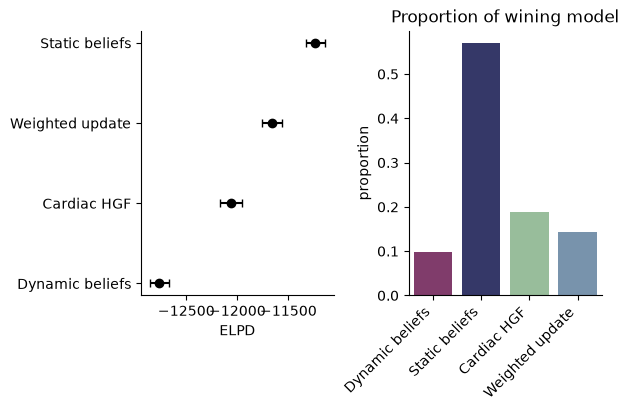

In [11]:
_, axs = plt.subplots(figsize=(6, 4), ncols=2)

# az.plot_compare no longer draws onto a provided axis in arviz>=1, so render the
# ELPD +/- SE per model directly on axs[0]
cmp = model_compare.sort_values("rank")
y_pos = np.arange(len(cmp))[::-1]
axs[0].errorbar(cmp["elpd"], y_pos, xerr=cmp["se"], fmt="o", color="k", capsize=3)
axs[0].set_yticks(y_pos)
axs[0].set_yticklabels(cmp.index)
axs[0].set(xlabel="ELPD", ylabel="")
axs[0].tick_params(axis="both", which="major", labelsize=10)

this_df = model_comparison_df[model_comparison_df["rank"] == 0]
colors = ["#92c396", "#6f94b5", "#dca8ae", "#a2618c"]
sns.countplot(
    this_df,
    x="model",
    stat="proportion",
    palette=["#8b3170", "#2c3071", "#92c396", "#6f94b5"],
    ax=axs[1],
)
axs[1].set_xticklabels(
    ["Dynamic beliefs", "Static beliefs", "Cardiac HGF", "Weighted update"],
    rotation=45,
    ha="right",
    fontsize=10,
)
axs[1].set(title="Proportion of wining model", xlabel=None)

sns.despine()

plt.savefig(
    Path().cwd().parent.parent / "figures" / "figure_5_model_comparison.svg",
    bbox_inches="tight",
)

In [12]:
print(f"Bayesian psychophysics: {sum(this_df.index == 'standard')}")
print(f"Cardiac beliefs: {sum(this_df.index == 'cardiac_beliefs')}")
print(f"Weighted update: {sum(this_df.index == 'weighted')}")
print(f"Cardiac HGF: {sum(this_df.index == 'cardiac_hgf')}")

Bayesian psychophysics: 51
Cardiac beliefs: 295
Weighted update: 74
Cardiac HGF: 98
